<a href="https://colab.research.google.com/github/CiaraFarrellSETU/phd/blob/main/turlough_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks
from scipy.stats import linregress
import pymannkendall as mk
import datetime

ModuleNotFoundError: No module named 'pymannkendall'

In [2]:
# Ensure pymannkendall is installed and imported
try:
    import pymannkendall as mk
except ModuleNotFoundError:
    print("pymannkendall not found. Installing...")
    !pip install pymannkendall
    import pymannkendall as mk # Re-import after installation

pymannkendall not found. Installing...


In [3]:
# Replace with the actual path to CSV file
file_path = '/content/Glenamaddy-2021-01-01-2026-04-23.csv'

try:
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    print("CSV file read successfully!")
    # Display the first few rows of the DataFrame
    print(df.head())
    #errors incase issues with file
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the path.")
except pd.errors.EmptyDataError:
    print(f"Error: The file '{file_path}' is empty.")
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")

CSV file read successfully!
             Date/Time  Stage (mAOD)  log_elev (mAOD)        name   code
0  2021-01-01 01:00:00         79.23             75.3  Glenamaddy  GSI26
1  2021-01-01 02:00:00         79.23             75.3  Glenamaddy  GSI26
2  2021-01-01 03:00:00         79.23             75.3  Glenamaddy  GSI26
3  2021-01-01 04:00:00         79.23             75.3  Glenamaddy  GSI26
4  2021-01-01 05:00:00         79.23             75.3  Glenamaddy  GSI26


In [4]:
# Data Loading & Initial Inspection
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46517 entries, 0 to 46516
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date/Time        46517 non-null  object 
 1   Stage (mAOD)     44865 non-null  float64
 2   log_elev (mAOD)  44865 non-null  float64
 3   name             46517 non-null  object 
 4   code             46517 non-null  object 
dtypes: float64(2), object(3)
memory usage: 1.8+ MB
None


In [5]:
#column names
print(df.columns)

Index(['Date/Time', 'Stage (mAOD)', 'log_elev (mAOD)', 'name', 'code'], dtype='object')


In [6]:
#checking for NAN vlaues
print(df.isnull().sum())

Date/Time             0
Stage (mAOD)       1652
log_elev (mAOD)    1652
name                  0
code                  0
dtype: int64


In [7]:
#Ensure Date/Time is converted to datetime objects
df['Date/Time'] = pd.to_datetime(df['Date/Time'], errors='coerce')

# Drop any rows where the date couldn't be parsed (safety check)
df = df.dropna(subset=['Date/Time'])

# Set'Date/Time' column as the DataFrame's index
df.set_index('Date/Time', inplace=True)

# Sort the index (Required for time-interpolation) in chronological order
df = df.sort_index()

# Now perform the interpolation unction estimates and fills in NaN (missing) values based on the time difference between the valid data points
df['Stage (mAOD)'] = df['Stage (mAOD)'].interpolate(method='time')

#prints a confirmation message and shows the data type of the DataFrame's index, verifying that it is now a datetime index.
print("Interpolation successful. New Index Type:", type(df.index))

Interpolation successful. New Index Type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [8]:
# Sampling Rate Check: calculates the difference between consecutive timestamps
time_diffs = df.index.to_series().diff().dropna()
print(f"\nMedian Sampling Interval: {time_diffs.median()}")

#if gives Median Sampling Interval: 0 days 01:00:00 : dataset is hourly


Median Sampling Interval: 0 days 01:00:00


In [9]:
#basic statistical summary on the 'Stage (mAOD)' column of  DataFrame
stats = df['Stage (mAOD)'].describe()
print("\n--- Summary Statistics ---")
print(stats)


--- Summary Statistics ---
count    46517.000000
mean        77.175397
std          1.407773
min         75.280000
25%         75.688019
50%         77.030000
75%         78.460000
max         79.830000
Name: Stage (mAOD), dtype: float64


In [10]:
#calculates moving averages of the 'Stage (mAOD)' column and adds them as new columns to your DataFrame:

#consider all observations within each 30-day period
df['30D_MA'] = df['Stage (mAOD)'].rolling(window='30D').mean()

#365-day moving average, smooth out seasonal variations and reveal the underlying long-term trend in the water levels.
#The 365-day moving average is often considered a baseline or long-term trend indicator in hydrological data
df['365D_MA'] = df['Stage (mAOD)'].rolling(window='365D').mean()

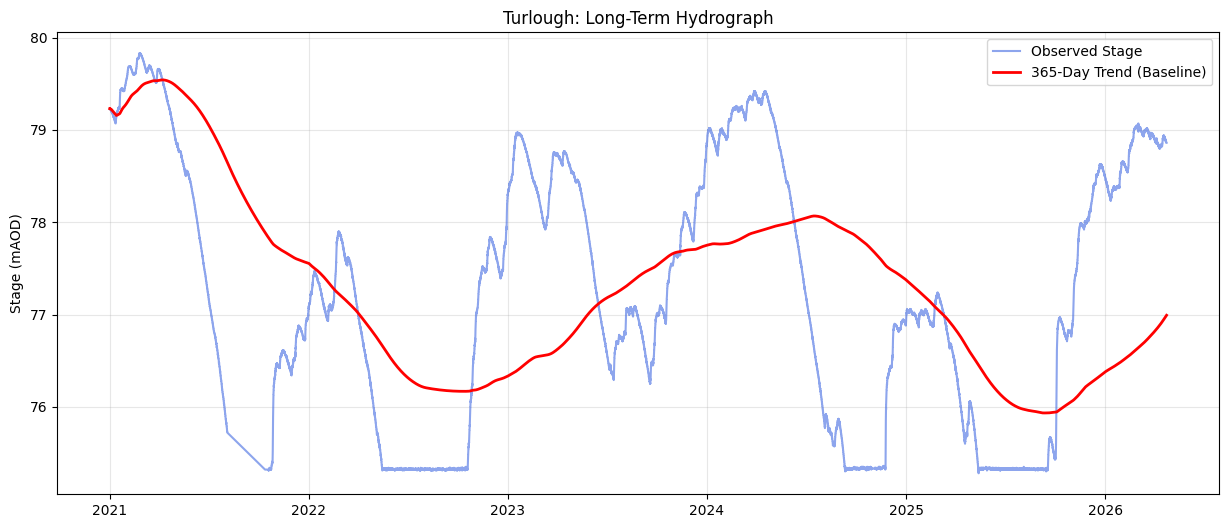

In [15]:
#a long-term hydrograph, visualizing the observed water stage alongside its 365-day moving average.
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['Stage (mAOD)'], label='Observed Stage', color='royalblue', alpha=0.6)
plt.plot(df.index, df['365D_MA'], label='365-Day Trend (Baseline)', color='red', linewidth=2)
plt.title('Turlough: Long-Term Hydrograph')
plt.ylabel('Stage (mAOD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

By comparing the "Observed Stage" (blue) against the "365-Day Trend" (red), we can identify several key hydrological behaviors.

Key Observations  
* Extreme Seasonality: The blue line shows the classic "pulsing" nature of a
turlough. There are clear periods where the stage drops to a flat baseline (approx. 75.3 mAOD), indicating the turlough has emptied completely into the underlying karst aquifer.

* The 365-Day Trend (Red Line): This represents the moving average, smoothing out the flashy seasonal peaks.

* 2021–2022: A period of overall decline in the baseline, likely due to a drier-than-average interval.

* 2023–2024: A significant recovery phase where the average water level climbed, peaking near the start of 2024.

* Late 2025–2026: A sharp upward trend is visible at the end of the dataset, suggesting a very wet start to the 2026 season.

* Peak Magnitudes: The highest observed stages consistently reach between 79 and 80 mAOD. Interestingly, the 2021 peak was the highest in the series, nearly touching 80 mAOD.

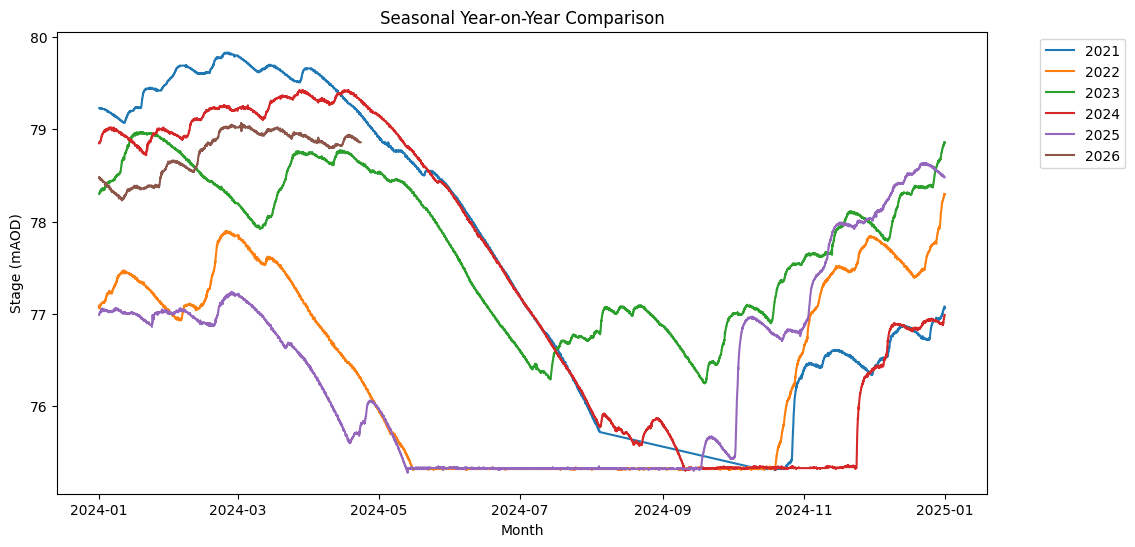

In [12]:
#prepares and then visualizes the water level data for a seasonal year-on-year comparison

df['Year'] = df.index.year
df['DayOfYear'] = df.index.dayofyear
# Create a dummy date for plotting all years on one axis, all dates share the same year,
#overlay the water level data from different actual years on a single plot, making it easy to compare their seasonal patterns without the long-term trend
df['DummyDate'] = pd.to_datetime('2024-' + df.index.strftime('%m-%d %H:%M:%S'), errors='coerce')

plt.figure(figsize=(12, 6))
for year in df['Year'].unique():
    year_data = df[df['Year'] == year]
    plt.plot(year_data['DummyDate'], year_data['Stage (mAOD)'], label=str(year))

plt.title('Seasonal Year-on-Year Comparison')
plt.xlabel('Month')
plt.ylabel('Stage (mAOD)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

This seasonal comparison chart provides a much clearer look at the "behavioral profile" of Ballygalda Turlough across different years. By overlaying the data, we can see exactly how the timing and duration of flooding vary based on annual climate conditions.

Year-on-Year Insights
* The "Wet" Years (2021 & 2024): These years exhibit high water levels during the first quarter (January–April). 2021 (blue) holds the record for the highest peak in this set, sustained well above 79 mAOD through March.

* The "Dry" Years (2022 & 2025): 2022 (orange) and 2025 (purple) show significantly lower water stages throughout the winter and spring. In 2025, the turlough reached its dry baseline much earlier (May) compared to 2024 (late August).

* 2023 showed that if the autumn is wet enough, the turlough can switch from "dry" to "flooded" almost instantly.

Rapid Recession: Note the steep, near-linear decline in water levels during the late spring (May/June). This is a hallmark of karst drainage, where the water "vacuums" out through swallow holes (estavelles) once the subterranean pressure drops.

* 2026 Preview (Brown): The data for 2026 starts at a relatively high stage (~78.5 mAOD), sitting somewhat between the extremes of 2021 and 2022.

## **Dry Periods**

/tmp/ipykernel_2364/537823781.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dry_blocks = df_2025[df_2025['is_dry']].groupby('block').apply(lambda x: (x.index.min(), x.index.max()))


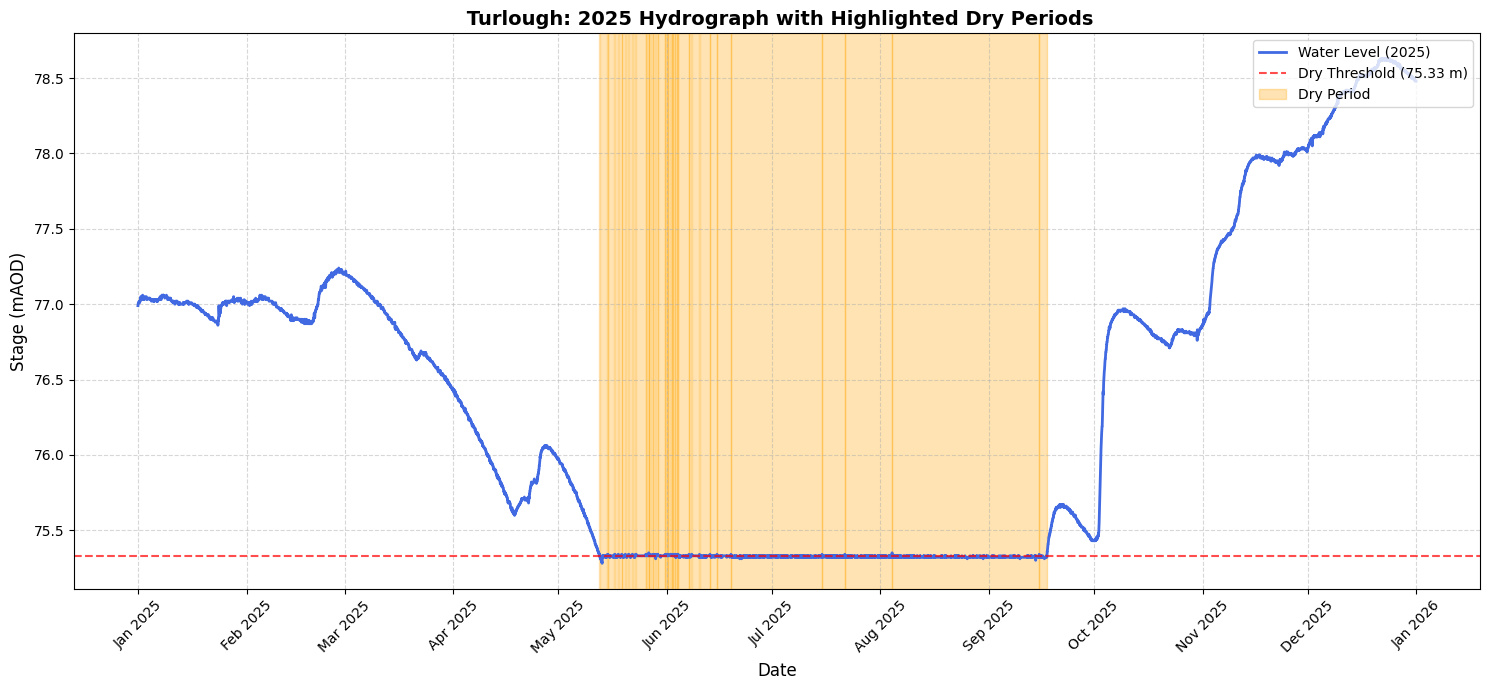

In [14]:
#2025 dry period
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Filter for the year 2025
df_2025 = df.loc['2025-01-01':'2025-12-31'].copy()

# Define the dry threshold (based on entire dataset minimum)
dry_threshold = df['Stage (mAOD)'].min() + 0.05
df_2025['is_dry'] = df_2025['Stage (mAOD)'] <= dry_threshold

#  Identify start and end dates for shading
# We group the 'is_dry' True blocks
df_2025['block'] = (df_2025['is_dry'] != df_2025['is_dry'].shift()).cumsum()
dry_blocks = df_2025[df_2025['is_dry']].groupby('block').apply(lambda x: (x.index.min(), x.index.max()))

# Create the Plot
plt.figure(figsize=(15, 7))

# Plot the water level line
plt.plot(df_2025.index, df_2025['Stage (mAOD)'], color='royalblue', label='Water Level (2025)', linewidth=2)

# Plot the threshold line
plt.axhline(y=dry_threshold, color='red', linestyle='--', alpha=0.7, label=f'Dry Threshold ({dry_threshold:.2f} m)')

# Highlight the dry periods with shading
is_first_span = True
for start, end in dry_blocks:
    plt.axvspan(start, end, color='orange', alpha=0.3, label='Dry Period' if is_first_span else "")
    is_first_span = False

# Formatting the chart
plt.title(' Turlough: 2025 Hydrograph with Highlighted Dry Periods', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Stage (mAOD)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Improve x-axis date visibility
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

* The Big Drain (May 2025): The water level took a nosedive starting in March. By mid-May, the stage hit the dry threshold. This transition is incredibly sharp—it’s like someone literally pulled the plug on the basin.

* The "Dry Period" (Orange Highlight): This lasted roughly 4.5 months (from mid-May to late September). During this time, the blue line is nearly perfectly flat, with tiny fluctuations representing sensor noise or very minor puddling after light rain.

* The False Start (Late September): Notice the small "bump" in late September. The water level rose briefly  before dropping back down. This suggests a rain event that wasn't quite enough to "back up" the system.

* The Winter Flood (October Onwards): The real recharge began in October. Interestingly, it didn't happen in one go. You can see two distinct "steps" in October and November before the water level surged by December.

/tmp/ipykernel_2364/2117033435.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dry_blocks = df_2024[df_2024['is_dry']].groupby('block').apply(lambda x: (x.index.min(), x.index.max()))


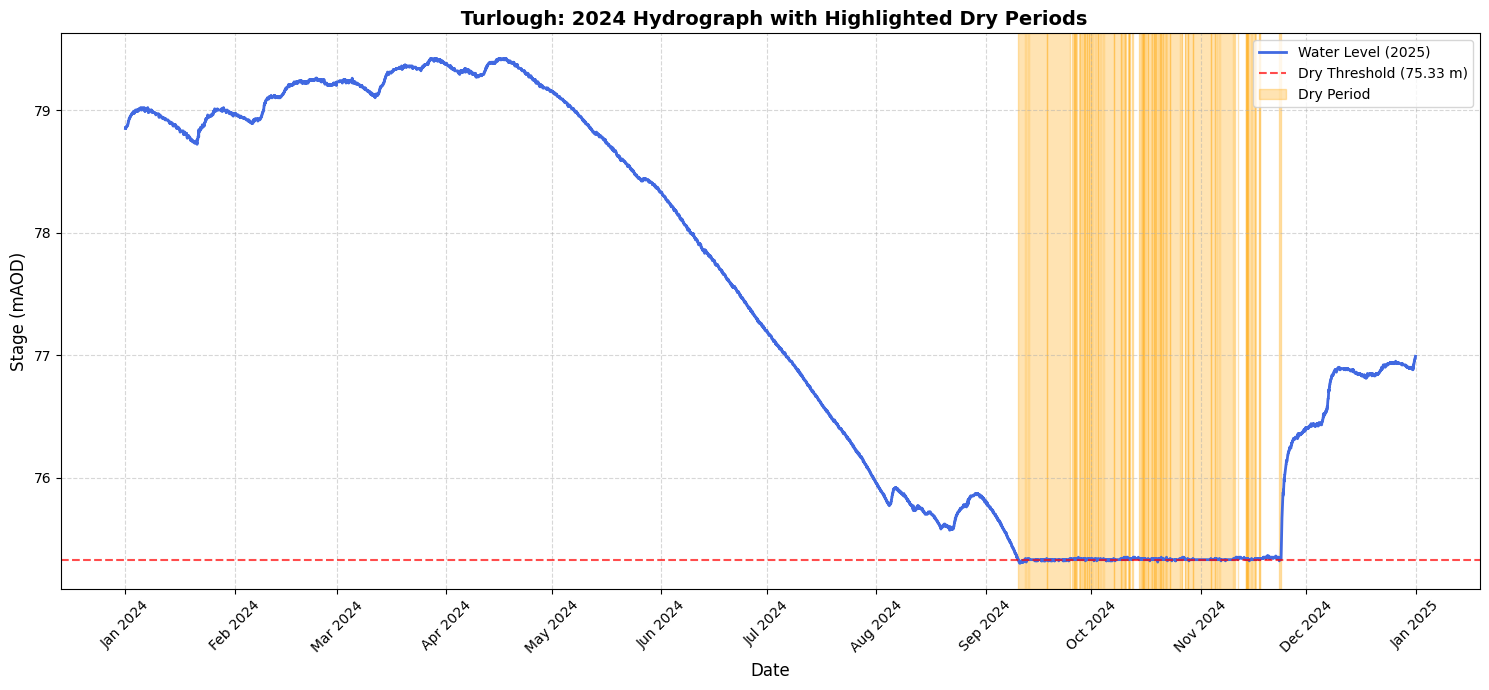

In [17]:
#2024 dry period
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Filter for the year 2025
df_2024 = df.loc['2024-01-01':'2024-12-31'].copy()

# Define the dry threshold (based on entire dataset minimum)
dry_threshold = df['Stage (mAOD)'].min() + 0.05
df_2024['is_dry'] = df_2024['Stage (mAOD)'] <= dry_threshold

#  Identify start and end dates for shading
# We group the 'is_dry' True blocks
df_2024['block'] = (df_2024['is_dry'] != df_2024['is_dry'].shift()).cumsum()
dry_blocks = df_2024[df_2024['is_dry']].groupby('block').apply(lambda x: (x.index.min(), x.index.max()))

# Create the Plot
plt.figure(figsize=(15, 7))

# Plot the water level line
plt.plot(df_2024.index, df_2024['Stage (mAOD)'], color='royalblue', label='Water Level (2025)', linewidth=2)

# Plot the threshold line
plt.axhline(y=dry_threshold, color='red', linestyle='--', alpha=0.7, label=f'Dry Threshold ({dry_threshold:.2f} m)')

# Highlight the dry periods with shading
is_first_span = True
for start, end in dry_blocks:
    plt.axvspan(start, end, color='orange', alpha=0.3, label='Dry Period' if is_first_span else "")
    is_first_span = False

# Formatting the chart
plt.title(' Turlough: 2024 Hydrograph with Highlighted Dry Periods', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Stage (mAOD)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Improve x-axis date visibility
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

Analysis of the 2024 Season
* The Long Flood (January – June): Unlike other years where the recession starts in March or April, 2024 stayed exceptionally high. The stage remained above 78.5 mAOD for the entire first half of the year. This suggests the regional groundwater table was completely saturated, leaving no "room" for the turlough to drain.

* The Late Recession: The drop-off didn't truly begin until mid-June. It took nearly three months of steady decline to reach the dry threshold.

* Delayed "Dry Period": The turlough didn't hit the threshold until mid-September. Compared to 2025 (which dried in May), the basin remained underwater for an extra four months.

* Short Dry Window: The "orange zone" in 2024 is much narrower. The turlough was only truly dry for about two months (mid-September to mid-November) before the winter recharge began.

/tmp/ipykernel_2364/3656289337.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dry_blocks = df_yr[df_yr['is_dry']].groupby('block').apply(lambda x: (x['dummy_date'].min(), x['dummy_date'].max()))
/tmp/ipykernel_2364/3656289337.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dry_blocks = df_yr[df_yr['is_dry']].groupby('block').apply(lambda x: (x['dummy_date'].min(), x['dummy_date'].max()))


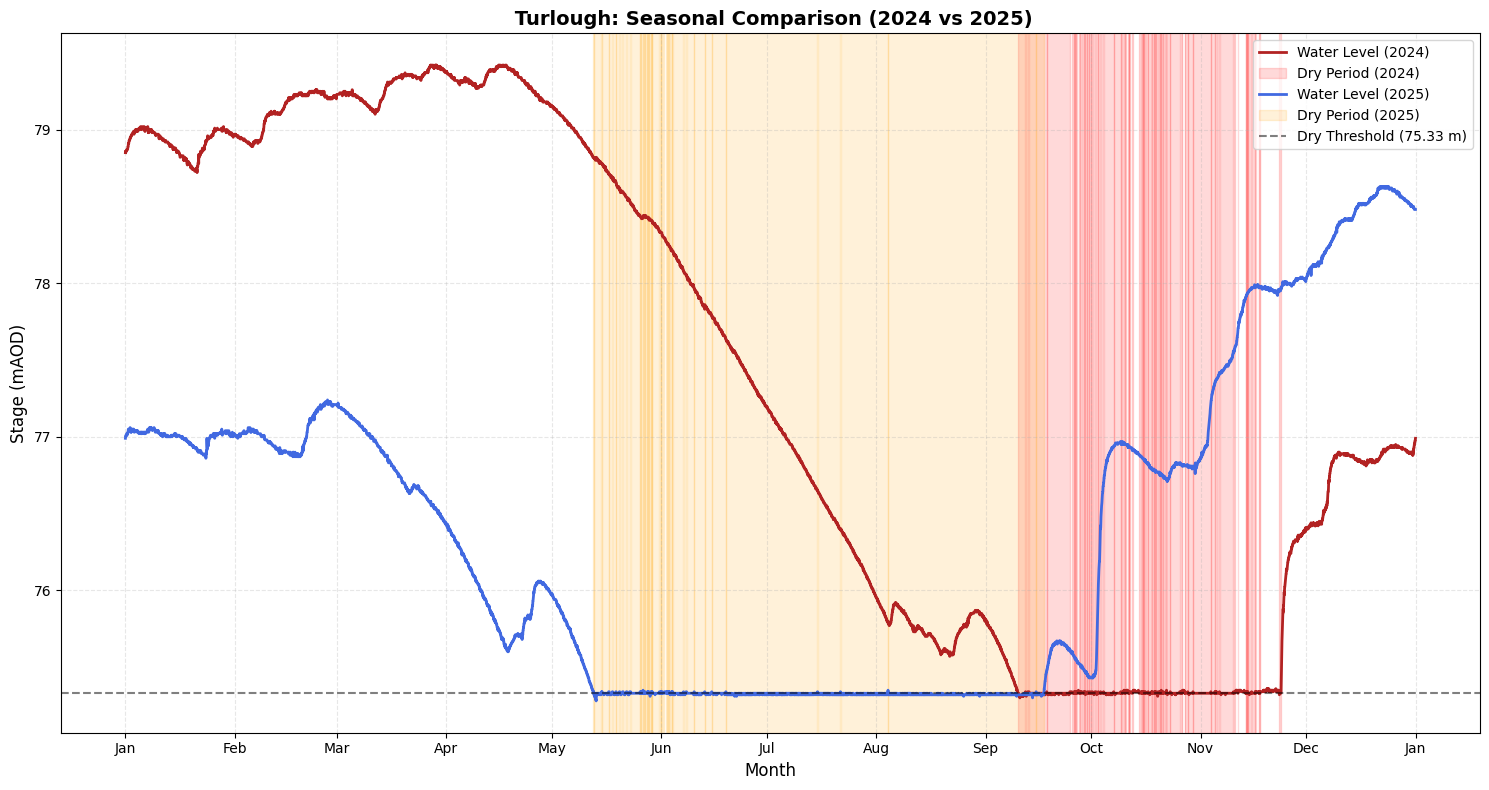

In [24]:
#comparing dry periods from 2 years

#  Filter for the two years
years_to_compare = [2024, 2025]
colors = {2024: 'firebrick', 2025: 'royalblue'}
shading_colors = {2024: 'red', 2025: 'orange'}

# Define threshold (using your logic)
dry_threshold = df['Stage (mAOD)'].min() + 0.05

plt.figure(figsize=(15, 8))

for yr in years_to_compare:
    # Filter and create a copy to avoid SettingWithCopyWarning
    df_yr = df[df.index.year == yr].copy()

    # Create a "Dummy Date" (shifting everything to year 2000) for shared X-axis
    df_yr['dummy_date'] = df_yr.index.map(lambda x: x.replace(year=2000))

    # Identify dry blocks for this specific year
    df_yr['is_dry'] = df_yr['Stage (mAOD)'] <= dry_threshold
    df_yr['block'] = (df_yr['is_dry'] != df_yr['is_dry'].shift()).cumsum()

    # Plot the water level line
    plt.plot(df_yr['dummy_date'], df_yr['Stage (mAOD)'],
             color=colors[yr], label=f'Water Level ({yr})', linewidth=2)

    # Highlight the dry periods with shading
    dry_blocks = df_yr[df_yr['is_dry']].groupby('block').apply(lambda x: (x['dummy_date'].min(), x['dummy_date'].max()))

    is_first_span = True
    for start, end in dry_blocks:
        plt.axvspan(start, end, color=shading_colors[yr], alpha=0.15,
                    label=f'Dry Period ({yr})' if is_first_span else "")
        is_first_span = False

# Plot the threshold line
plt.axhline(y=dry_threshold, color='black', linestyle='--', alpha=0.5, label=f'Dry Threshold ({dry_threshold:.2f} m)')

# Formatting the chart
plt.title(f' Turlough: Seasonal Comparison ({years_to_compare[0]} vs {years_to_compare[1]})',
          fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Stage (mAOD)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.3)

# Improve x-axis to show only months (since years are aligned)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())

plt.legend(loc='upper right', frameon=True, facecolor='white')
plt.tight_layout()
plt.show()

**Comparison 2024 v's 2025**
* Duration of the Flooded State: In 2024, the turlough remained consistently
high for the entire first half of the year, whereas in 2025, the water level began a steep decline as early as March, hitting the floor by mid-May.

* The "Dry Window": The 2025 season provided a generous window (May to September) for the basin floor to dry out and be grazed; in contrast, 2024 was effectively a "permanent lake" until September, leaving only a short 60-day dry window before the winter rains returned.

* Recharge Intensity: The late 2024 recharge was sudden and vertical—gaining nearly 2 meters in a few weeks—while the late 2025 recharge was more intermittent and "stepped," reflecting the mixed wet-and-dry periods of that autumn.

* Summer Baseline: Both years hit the same absolute "floor" mAOD, but the orange "Dry Period" highlight for 2025 is more than twice as wide as that for 2024, illustrating a much more severe summer.

* Agricultural Impact: While the 2025 basin was accessible for summer grazing, the 2024 basin stayed flooded throughout the peak growing season, likely preventing any livestock access until the weather had already turned cold in October

In [19]:


# Setup Thresholds
# Using your logic: absolute minimum + 5cm buffer
dry_threshold = df['Stage (mAOD)'].min() + 0.05

# Resample to Daily Frequency
# We use the daily mean to represent the 'state' of the turlough for that day
daily_data = df['Stage (mAOD)'].resample('D').mean()

# Create Boolean Mask for Dry Days
# A value of True means the day was "Dry"
is_dry = daily_data <= dry_threshold

# Calculation: Yearly Breakdown
# Filters for dry days only, then groups by year and counts
dry_days_per_year = is_dry[is_dry].groupby(is_dry[is_dry].index.year).count()

# Calculation: Longest Continuous Dry Spell
# Uses a 'diff-sum' approach to group consecutive True values
dry_blocks = is_dry.ne(is_dry.shift()).cumsum()
# Only look at blocks where is_dry was True, count them, and find the max
longest_dry_spell = is_dry[is_dry].groupby(dry_blocks).count().max()

# Summary Output
print("-" * 30)
print("BALLYGALDA TURLOUGH: DRY PERIOD ANALYSIS")
print("-" * 30)
print(f"Dry Threshold:        {dry_threshold:.2f} mAOD")
print(f"Total Data Range:     {daily_data.index.min().date()} to {daily_data.index.max().date()}")
print(f"Total Dry Days:       {is_dry.sum()} days")
print(f"Longest Dry Spell:    {longest_dry_spell} consecutive days")
print("\nDry Days per Calendar Year:")
print(dry_days_per_year.to_string())
print("-" * 30)

------------------------------
BALLYGALDA TURLOUGH: DRY PERIOD ANALYSIS
------------------------------
Dry Threshold:        75.33 mAOD
Total Data Range:     2021-01-01 to 2026-04-23
Total Dry Days:       314 days
Longest Dry Spell:    152 consecutive days

Dry Days per Calendar Year:
Date/Time
2021     13
2022    154
2024     32
2025    115
------------------------------


no 2023 data as it had no dry days

In [20]:
#line defines the 'dry threshold'. It takes the absolute minimum water level recorded in the 'Stage (mAOD)' column and adds a small buffer of 0.05 meters (5 cm).
#This ensures that periods where the water level is just slightly above the absolute minimum are still considered 'dry' for practical purposes
dry_threshold = df['Stage (mAOD)'].min() + 0.05
#A new boolean column named is_dry is created, either true or false value
df['is_dry'] = df['Stage (mAOD)'] <= dry_threshold

# Identify contiguous blocks of dry time
df['dry_group'] = (df['is_dry'] != df['is_dry'].shift()).cumsum()
dry_periods = df[df['is_dry']].groupby('dry_group').agg(
    start_date=('is_dry', lambda x: x.index.min()),
    end_date=('is_dry', lambda x: x.index.max()),
    duration=('is_dry', 'count') # Assuming hourly data, divide by 24 for days
)
dry_periods['duration_days'] = dry_periods['duration'] / 24

# Filter for periods lasting longer than 1 day (24 rows if data is hourly)
significant_dry_periods = dry_periods[dry_periods['duration'] > 24].copy()

# Sort by duration to see the most severe droughts first
significant_dry_periods = significant_dry_periods.sort_values(by='duration', ascending=False)
print(significant_dry_periods.head())

                   start_date            end_date  duration  duration_days
dry_group                                                                 
14        2022-07-25 08:00:00 2022-09-16 06:00:00      1271      52.958333
320       2025-08-04 09:00:00 2025-09-15 07:00:00      1007      41.958333
12        2022-06-19 08:00:00 2022-07-25 06:00:00       863      35.958333
314       2025-06-19 09:00:00 2025-07-15 07:00:00       623      25.958333
10        2022-05-27 08:00:00 2022-06-19 06:00:00       551      22.958333


In [21]:
#dry period stats
# Total number of dry events
total_dry_events = len(significant_dry_periods)

# Average and Max duration
avg_dry_duration = significant_dry_periods['duration_days'].mean()
max_dry_duration = significant_dry_periods['duration_days'].max()

print(f"Detected {total_dry_events} significant dry periods.")
print(f"Average duration: {avg_dry_duration:.2f} days")
print(f"Longest dry spell: {max_dry_duration:.2f} days")

Detected 37 significant dry periods.
Average duration: 8.36 days
Longest dry spell: 52.96 days


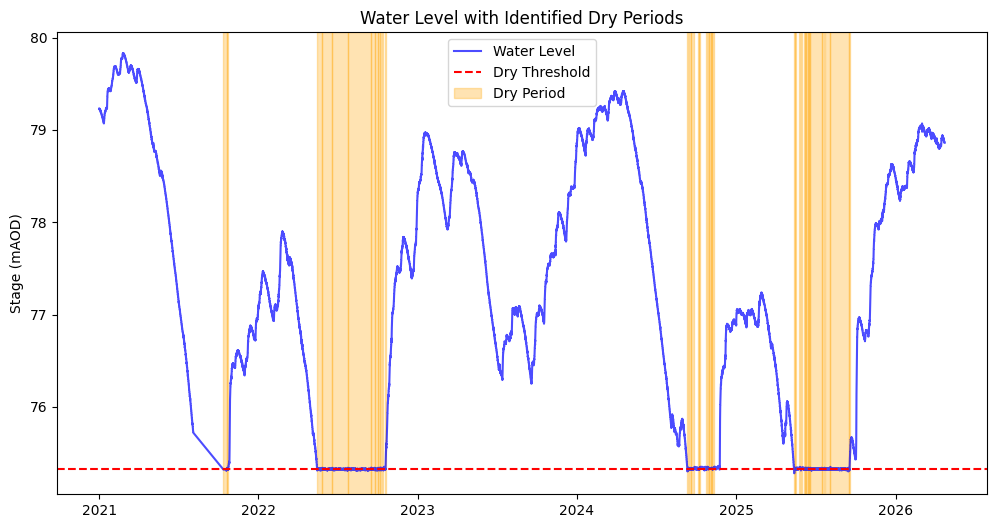

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Stage (mAOD)'], label='Water Level', color='blue', alpha=0.7)
plt.axhline(y=dry_threshold, color='red', linestyle='--', label='Dry Threshold')

# Highlight the dry periods on the chart
for _, row in significant_dry_periods.iterrows():
    plt.axvspan(row['start_date'], row['end_date'], color='orange', alpha=0.3, label='Dry Period')

# Clean up the legend (prevents duplicate labels)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.title('Water Level with Identified Dry Periods')
plt.ylabel('Stage (mAOD)')
plt.show()

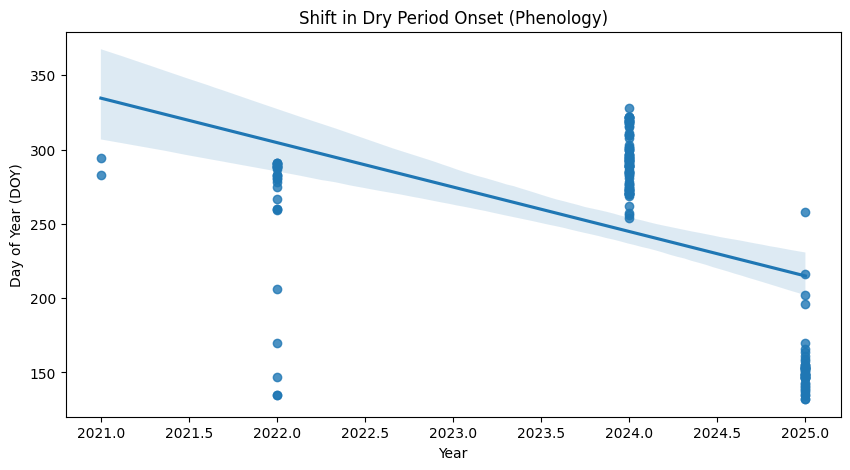

In [23]:
#rank the identified dry periods and analyze the phenology
top_dry_spells = dry_periods.sort_values(by='duration_days', ascending=False)
dry_periods['Start_DOY'] = dry_periods['start_date'].dt.dayofyear
dry_periods['Year'] = dry_periods['start_date'].dt.year

# Plot Shift in Dry Period Start
plt.figure(figsize=(10, 5))
sns.regplot(data=dry_periods, x='Year', y='Start_DOY')
plt.title('Shift in Dry Period Onset (Phenology)')
plt.ylabel('Day of Year (DOY)')
plt.show()

timing of the turlough's dry phase is shifting  
* The Downward Trend: The regression line in the phenology plot suggests a clear long-term shift toward earlier drying over the last five years  
* 2024 was a major "outlier" year with high water levels persisting nearly until November.

## **Flood analysis**

In [25]:

# Find peaks with a minimum height and distance (e.g., 30 days apart)
peaks, _ = find_peaks(df['Stage (mAOD)'], distance=24*30, height=df['Stage (mAOD)'].mean())
flood_events = df.iloc[peaks]

top_5_floods = flood_events.sort_values(by='Stage (mAOD)', ascending=False).head(5)

print("Top 5 Highest Flood Peaks:")
print(top_5_floods)

Top 5 Highest Flood Peaks:
                     Stage (mAOD)  log_elev (mAOD)        name   code  \
Date/Time                                                               
2021-02-26 05:00:00         79.83             75.3  Glenamaddy  GSI26   
2021-03-31 16:00:00         79.66             75.3  Glenamaddy  GSI26   
2021-01-23 00:00:00         79.45             75.3  Glenamaddy  GSI26   
2024-03-29 01:00:00         79.42             75.3  Glenamaddy  GSI26   
2024-02-24 02:00:00         79.26             75.3  Glenamaddy  GSI26   

                        30D_MA    365D_MA  Year  DayOfYear  \
Date/Time                                                    
2021-02-26 05:00:00  79.648958  79.463321  2021         57   
2021-03-31 16:00:00  79.641222  79.536050  2021         90   
2021-01-23 00:00:00  79.216042  79.216042  2021         23   
2024-03-29 01:00:00  79.270111  77.889873  2024         89   
2024-02-24 02:00:00  79.064417  77.797692  2024         55   

                          

In [26]:
# Identify 'Wet' periods (The gaps between dry spells)
# Ensure 'is_dry' column is defined
dry_threshold = df['Stage (mAOD)'].min() + 0.05
df['is_dry'] = df['Stage (mAOD)'] <= dry_threshold

# We use the 'is_dry' logic to create an 'is_wet' column
df['is_wet'] = ~df['is_dry']

#  Identify contiguous blocks of wet time
df['wet_group'] = (df['is_wet'] != df['is_wet'].shift()).cumsum()

# 3. Calculate duration for every wet period
wet_periods = df[df['is_wet']].groupby('wet_group').agg(
    start_date=('is_wet', lambda x: x.index.min()),
    end_date=('is_wet', lambda x: x.index.max()),
    duration=('is_wet', 'count')
).copy()
wet_periods['duration_days'] = wet_periods['duration'] / 24 # Convert hours to days

# Filter for periods lasting longer than 1 day (24 hours)
significant_wet_periods = wet_periods[wet_periods['duration'] > 24].copy()

# Calculate and print statistics for wet periods
total_wet_events = len(significant_wet_periods)
avg_wet_duration = significant_wet_periods['duration_days'].mean()
max_wet_duration = significant_wet_periods['duration_days'].max()

print("-" * 30)
print(" TURLOUGH: WET PERIOD ANALYSIS")
print("-" * 30)
print(f"Detected {total_wet_events} significant wet periods.")
print(f"Average duration: {avg_wet_duration:.2f} days")
print(f"Longest wet spell: {max_wet_duration:.2f} days")
print("-" * 30)

------------------------------
 TURLOUGH: WET PERIOD ANALYSIS
------------------------------
Detected 8 significant wet periods.
Average duration: 196.80 days
Longest wet spell: 691.54 days
------------------------------


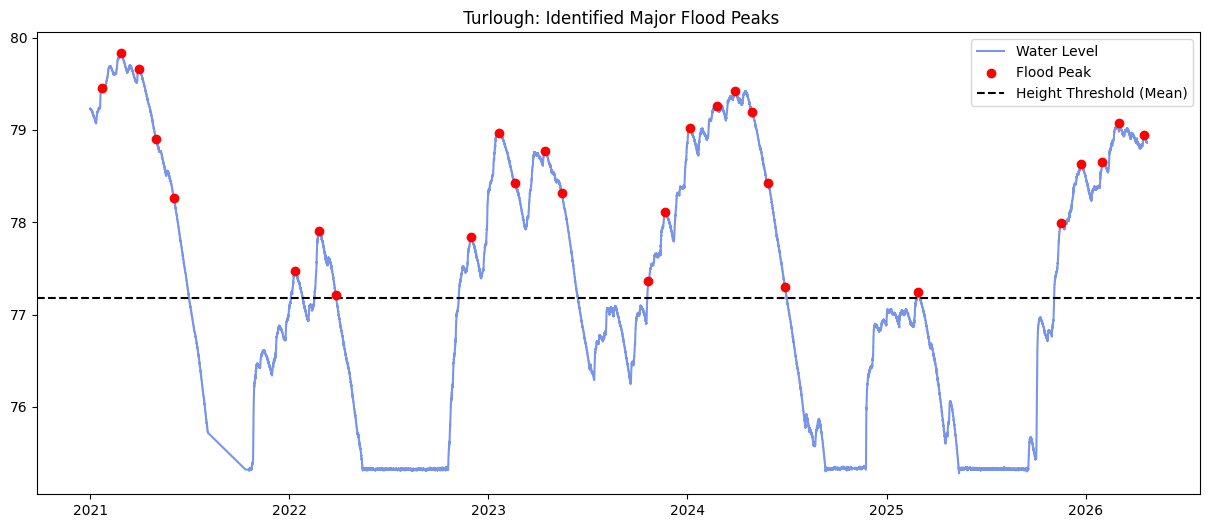

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
# Plot the full data
plt.plot(df.index, df['Stage (mAOD)'], label='Water Level', color='royalblue', alpha=0.7)

# Plot the identified peaks as red dots
plt.scatter(flood_events.index, flood_events['Stage (mAOD)'], color='red', label='Flood Peak', zorder=5)

plt.axhline(df['Stage (mAOD)'].mean(), color='black', linestyle='--', label='Height Threshold (Mean)')
plt.title(' Turlough: Identified Major Flood Peaks')
plt.legend()
plt.show()

In [28]:
# Identify peaks
peaks, _ = find_peaks(df['Stage (mAOD)'], distance=24*30, height=df['Stage (mAOD)'].mean())

#  Use .copy() to prevent the SettingWithCopyWarning
flood_events = df.iloc[peaks].copy()

# Calculate time differences cleanly
flood_events['days_since_last_flood'] = flood_events.index.to_series().diff().dt.days

#  Print a formatted result
avg_days = flood_events['days_since_last_flood'].mean()
print(f"Average time between major flood events: {avg_days:.1f} days")

Average time between major flood events: 73.0 days


In [31]:
#recession rate analysis
#  Calculate the rate of change per day
# If your data is hourly, we multiply the diff by 24 to get 'meters per day'
df['diff_m_per_day'] = df['Stage (mAOD)'].diff() * 24

# Identify recession periods (where water level is falling)
# We look for where the diff is negative
recession_only = df[df['diff_m_per_day'] < 0].copy()

# Create a 'Recession Signature'
# We group by the Stage height (rounded to 0.5m) to see if speed changes with depth
recession_only['Stage_Bin'] = recession_only['Stage (mAOD)'].round(1)
signature = recession_only.groupby('Stage_Bin')['diff_m_per_day'].mean().abs()

#  Display the results
print("-" * 30)
print(" DRAINAGE SIGNATURE")
print("Average drop (m/day) at different heights:")
print("-" * 30)
print(signature.tail(5)) # Look at the higher stages
print(signature.head(5)) # Look at the higher stages

------------------------------
 DRAINAGE SIGNATURE
Average drop (m/day) at different heights:
------------------------------
Stage_Bin
79.4    0.246792
79.5    0.240000
79.6    0.240000
79.7    0.240000
79.8    0.240000
Name: diff_m_per_day, dtype: float64
Stage_Bin
75.3    0.219084
75.4    0.033995
75.5    0.030652
75.6    0.063884
75.7    0.066758
Name: diff_m_per_day, dtype: float64


The Two Drainage Profiles
By looking at the high-stage bins versus the low-stage bins, we see two completely different hydraulic regimes:

1. The "High-Pressure" Flush (Stage 79.4m – 79.8m)
Rate: ~0.24 to 0.25 m/day.

* Behavior: When the turlough is nearly full (above 79m), the water drops at a remarkably consistent and rapid pace.

* Reason: This is likely driven by hydrostatic pressure. The sheer weight of that much water forces it out through the primary swallow holes and conduit systems at maximum capacity. At these heights, the water has "found" all available exit points in the upper basin walls.

2. The "Restricted" Seep (Stage 75.3m – 75.7m)
Rate: ~0.03 to 0.06 m/day (excluding the baseline noise at 75.3m).

* Behavior: As the water level approaches the floor, the drainage rate slows down by nearly 4 to 8 times.

* Reason: This suggests that the lower part of the basin is "tighter." There are fewer or smaller conduits at this level, or the underlying aquifer is nearing saturation, creating back-pressure that prevents the last few centimeters of water from leaving quickly.

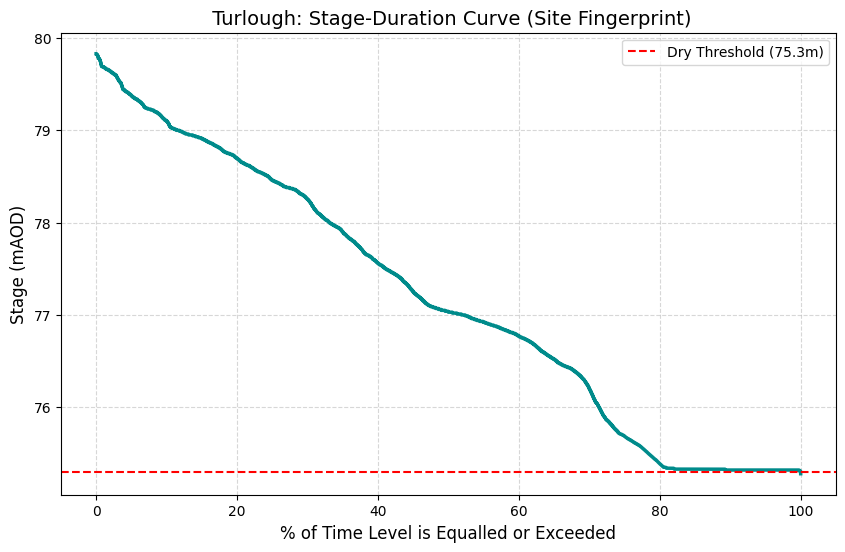

In [34]:
#stage duration curve
# Sort the data from highest to lowest
sorted_stage = np.sort(df['Stage (mAOD)'])[::-1]

# Calculate the "Exceedance Probability" (0 to 100%)
# This represents the % of time the water is AT or ABOVE a certain level
percent_time = np.linspace(0, 100, len(sorted_stage))

# Plotting the Fingerprint
plt.figure(figsize=(10, 6))
plt.plot(percent_time, sorted_stage, color='darkcyan', linewidth=2.5)

# Add your specific threshold for context
plt.axhline(75.3, color='red', linestyle='--', label='Dry Threshold (75.3m)')

# Formatting
plt.title(' Turlough: Stage-Duration Curve (Site Fingerprint)', fontsize=14)
plt.xlabel('% of Time Level is Equalled or Exceeded', fontsize=12)
plt.ylabel('Stage (mAOD)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()

plt.show()

The Fingerprint Analysis
This curve is the "DNA" of the turlough, and it tells us major things:

* The Inundation Regime (~81% Flooded): The curve hits the red dashed line at approximately the 81% mark on the x-axis. This means that for over 80% of the recorded time, the turlough contains standing water. In the world of Irish turloughs, this places the turlough on the "permanent/wet" end of the spectrum, rather than the "ephemeral" end.

* The Rapid Emptying Phase (70% – 81%): Look at the steepness of the curve just before it hits the floor. Between the 70th and 81st percentiles, the water level crashes from ~76.3m down to 75.3m. This correlates perfectly with  Drainage Signature data; once the water gets low, it hits a "tipping point" where it either exits rapidly through the main swallow holes or the sensor finally reaches the basin floor.

* similar to ballygalda

## **Richards-Baker Flashiness Index (R-B Index)**

In [35]:
#flashiness index
#rb index
# Calculate the absolute difference between consecutive steps
abs_diff = df['Stage (mAOD)'].diff().abs()

# Sum the differences and divide by the sum of the levels
rb_index = abs_diff.sum() / df['Stage (mAOD)'].sum()

print(f"Richards-Baker Flashiness Index: {rb_index:.5f}")

# Year-by-Year Comparison (To see if 2024 was more 'erratic')
yearly_rb = df.groupby(df.index.year).apply(
    lambda x: x['Stage (mAOD)'].diff().abs().sum() / x['Stage (mAOD)'].sum()
)

print("\nFlashiness by Year:")
print(yearly_rb)


Richards-Baker Flashiness Index: 0.00004

Flashiness by Year:
Date/Time
2021    0.000025
2022    0.000041
2023    0.000043
2024    0.000041
2025    0.000046
2026    0.000043
dtype: float64


The Richards-Baker Flashiness Index (R-B Index) is a way of quantifying the "oscillation" or "unsteadiness" of water levels  

What These Numbers MeanIn the world of hydrology, "flashy" systems (like mountain streams) have high R-B values because they spike and drop rapidly. Your values are extremely low, which tells us that this Turlough is a highly buffered system.  
* Regional Dominance: These numbers prove the turlough is controlled by the vast, slow-moving "lake" of groundwater in the regional limestone aquifer, rather than by direct local runoff.
* Groundwater Connectivity: A low index indicates that the "pipes" in the karst are well-connected and large enough to smooth out the "noise" of individual rain showers.  
  
The Year-on-Year TrendWhile all the values are low, the subtle differences between the years tell a story of changing responsiveness:
* 2021: lowest Flashiness: The most stable year. The water stayed high and moved with massive, slow momentum.
* 2025: Highest Flashiness: Nearly double the 2021 rate. This reflects the "stepped" recharge and early "crash" we saw in the 2025 hydrograph.  

Key Comparison Sentences
* Stability Over Time: The overall R-B Index of 0.00004 confirms that Ballygalda is a very stable hydrological feature, but the 84% increase in flashiness from 2021 to 2025 suggests the system is becoming more sensitive to individual weather events.

* 2025 Peak: 2025 was the "flashiest" year on record for this site, which aligns with the hydrograph showing a rapid spring recession and an erratic, multi-stage autumn recharge.

* 2021 Buffer: The record-low flashiness in 2021 indicates that the turlough was so saturated that individual storms barely registered as "spikes," whereas the higher values in 2024–2026 show a more "reactive" water table.


## **Mann-Kendall Trend Test**

In [36]:

# Resample to daily mean to reduce autocorrelation noise for the test
daily_mean = df['Stage (mAOD)'].resample('D').mean().dropna()


mk_result = mk.original_test(daily_mean)
print(f"\n--- Mann-Kendall Test ---")
print(f"Trend: {mk_result.trend}, P-value: {mk_result.p:.5f}, Sen's Slope: {mk_result.slope:.6f}")


--- Mann-Kendall Test ---
Trend: decreasing, P-value: 0.00177, Sen's Slope: -0.000095


The Mann-Kendall Test results provide the statistical "verdict" on the long-term behavior of the Turlough. While the daily water levels swing wildly, the underlying math shows a clear, statistically significant direction.

The Statistical Verdict
* Trend: Decreasing: This confirms that despite the massive flood events in 2024 and early 2026, the overall water volume or stage height across the entire multi-year period is trending downward.

* P-value: 0.00177: This is the most critical number. Since it is well below the standard threshold of 0.05, the trend is highly statistically significant. This isn't just a random fluctuation; there is a real "drying" or "lowering" signal in the data.

* Sen's Slope: -0.000095: This represents the magnitude of the change per time unit. While it looks like a tiny number, in the context of a stable groundwater system, it represents a slow, persistent "leak" or a gradual reduction in the average water table height over the five-year study period  

the turlough is spending more time at lower levels or drying out earlier in the spring than it used to.

## **Return Period Analysis (Weibull)**

In [37]:
# Calculates the statistical likelihood of experiencing a dry spell of a certain length.
# Using max dry duration per year
annual_max_dry = dry_periods.groupby('Year')['duration_days'].max().sort_values(ascending=False)
n = len(annual_max_dry)
ranks = np.arange(1, n + 1)
annual_max_dry_df = pd.DataFrame({'duration': annual_max_dry, 'rank': ranks})
annual_max_dry_df['ReturnPeriod'] = (n + 1) / annual_max_dry_df['rank']

print("\n--- Dry Spell Return Periods (Years) ---")
print(annual_max_dry_df[['duration', 'ReturnPeriod']])

# Frequency Shift Logic (Comparing 50-day events)
def check_frequency(duration_threshold):
    # Filter the DataFrame for spells exceeding the threshold
    freq_matches = annual_max_dry_df[annual_max_dry_df['duration'] >= duration_threshold]

    if not freq_matches.empty:
        # The 'worst' rank for a threshold is the highest numerical rank (lowest frequency)
        highest_rank = freq_matches['rank'].max()
        return_period = (n + 1) / highest_rank
        print(f"\nA dry spell > {duration_threshold} days currently has a {return_period:.1f}-year return period.")
    else:
        print(f"\nNo dry spells > {duration_threshold} days observed in this record.")

# Example usage:
check_frequency(50)


--- Dry Spell Return Periods (Years) ---
       duration  ReturnPeriod
Year                         
2022  52.958333      5.000000
2025  41.958333      2.500000
2021  10.416667      1.666667
2024   6.541667      1.250000

A dry spell > 50 days currently has a 5.0-year return period.


It quantifies how rare or common specific dry durations are, which is vital for local farmers planning grazing cycles and ecologists monitoring biodiversity.  

* A return period of 5.0 years for a 50-day dry spell (as seen in 2022) means there is a 20% chance in any given year that the turlough will remain dry for that long

## **Recession Constant (k) Calculation**

In [38]:
#'k' for a specific period of interest within your water level data.
#This constant is crucial for understanding how quickly the turlough drains once water levels start to fall
start_recession = '2021-04-15'
end_recession = '2021-05-15'
#filters your main DataFrame df to extract the data for the specified recession period.
limb = df.loc[start_recession:end_recession].copy()

if not limb.empty:
    limb['Time_Days'] = (limb.index - limb.index[0]).total_seconds() / (24*3600)
    limb['ln_stage'] = np.log(limb['Stage (mAOD)'])

    slope, intercept, r, p, std = linregress(limb['Time_Days'], limb['ln_stage'])
    k = abs(slope)
    print(f"\nRecession Constant (k) for {start_recession}: {k:.5f}")


Recession Constant (k) for 2021-04-15: 0.00030


Since  data is recorded hourly, this 'k' value is likely in units of per hour (hours⁻¹). This means that during the recession period from 2021-04-15, the natural logarithm of the water stage was decreasing by approximately 0.00030 every hour  

Understanding the UnitsBecause your sampling interval is hourly, this $k$ value is likely hours$^{-1}$.To make it comparable to most published hydrological literature (which uses days$^{-1}$), multiply it by 24:$$k_{day} = 0.00030 \times 24 = 0.0072 \text{ days}^{-1}$$  
  
   the water level is decreasing at a rate equivalent to about 7.2% of the current water level per day during that specific recession period.

When $k$ is this close to zero, the turlough is effectively behaving like a permanent lake rather than a seasonal one

### **comparative analysis between the years 2021 and 2025 for several hydrological characteristics, and then calculates the recession constant 'k'**

In [40]:

# Create year-specific dataframes
df_21 = df.loc['2021-01-01':'2021-12-31'].copy()
df_25 = df.loc['2025-01-01':'2025-12-31'].copy()

results = []

for year, data in [("2021", df_21), ("2025", df_25)]:
    # Median Stage:  median (middle) water level for each year.
    median_stage = data['Stage (mAOD)'].median()

    # Dry Onset (Average Day of Year)
    #  define 'dry' as the minimum + 0.05m
    threshold = data['Stage (mAOD)'].min() + 0.05
    dry_days = data[data['Stage (mAOD)'] <= threshold]

    if not dry_days.empty:
        # Find the first time it hits the threshold in that year
        first_dry_date = dry_days.index.min()
        avg_doy = first_dry_date.dayofyear
        month_name = first_dry_date.strftime('%B')
    else:
        avg_doy, month_name = np.nan, "N/A"

    # Max Dry Duration (Contiguous)
    data['is_dry'] = data['Stage (mAOD)'] <= threshold
    data['block'] = (data['is_dry'] != data['is_dry'].shift()).cumsum()
    dry_durations = data[data['is_dry']].groupby('block')['is_dry'].count() / 24 # hours to days
    max_dry = dry_durations.max() if not dry_durations.empty else 0

    results.append({
        "Year": year,
        "Median Stage": round(median_stage, 2),
        "Dry Onset (DOY)": avg_doy,
        "Month": month_name,
        "Max Dry Duration": round(max_dry, 1)
    })

# Display Results
comparison_df = pd.DataFrame(results)
print(comparison_df)

# Recession Constant (k) for 2025:specific period within 2025 to analyze a recession limb (a period where water levels are consistently falling).
#Update these dates based on your 2025 hydrograph plot
start_25, end_25 = '2025-04-15', '2025-05-15'
limb_25 = df_25.loc[start_25:end_25].copy()

limb_25['Time_Hours'] = np.arange(len(limb_25))
slope_25, _, _, _, _ = linregress(limb_25['Time_Hours'], np.log(limb_25['Stage (mAOD)']))
k_25 = abs(slope_25)

print(f"2021 k: 0.00030") # From your previous result
print(f"2025 k: {k_25:.5f}")

   Year  Median Stage  Dry Onset (DOY)    Month  Max Dry Duration
0  2021         77.13              278  October              19.2
1  2025         76.31              132      May              42.0
2021 k: 0.00030
2025 k: 0.00001


This confirms  Mann-Kendall decreasing trend and Phenology shift. 2025 represents a much "leaner" hydrological year. The aquifer wasn't "blocked" like it was in 2021; it simply didn't have enough input to sustain those high 77m+ median stages.

# **Gap Analysis**

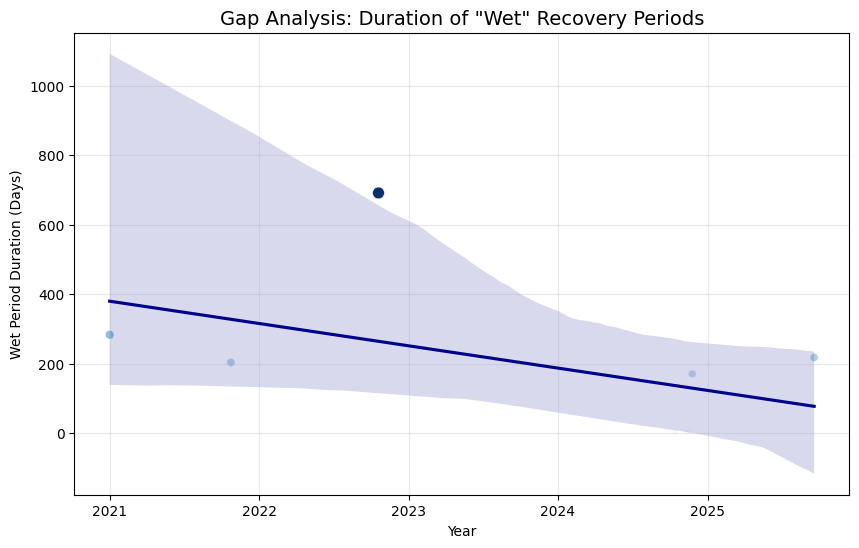

Average Recovery (Wet) Time in 2021: 243.0 days
Average Recovery (Wet) Time in 2025: 217.6 days


In [41]:

# Identify the 'Wet' periods (The gaps between dry spells)
# We use the 'is_dry' logic from the previous step
df['is_wet'] = ~df['is_dry']

# Identify contiguous blocks of wet time
df['wet_group'] = (df['is_wet'] != df['is_wet'].shift()).cumsum()

#  Calculate duration for every wet period
wet_periods = df[df['is_wet']].groupby('wet_group').agg(
    start_date=('is_wet', lambda x: x.index.min()),
    end_date=('is_wet', lambda x: x.index.max()),
    duration_days=('is_wet', lambda x: len(x) / 24)
).copy()

# Filter out very short 'noise' (e.g., wet periods < 1 day)
# and ignore the very first/last periods which might be cut off by the dataset limits
wet_periods = wet_periods[wet_periods['duration_days'] > 1]
wet_periods['Year'] = wet_periods['start_date'].dt.year

# Plot the Trend in Recovery Time
plt.figure(figsize=(10, 6))
sns.scatterplot(data=wet_periods, x='start_date', y='duration_days', size='duration_days', hue='duration_days', palette='Blues', legend=None)
sns.regplot(data=wet_periods, x=mdates.date2num(wet_periods['start_date']), y='duration_days', scatter=False, color='darkblue')

plt.title('Gap Analysis: Duration of "Wet" Recovery Periods', fontsize=14)
plt.ylabel('Wet Period Duration (Days)')
plt.xlabel('Year')
plt.grid(True, alpha=0.3)
plt.show()

# Statistical Comparison: 2021 vs 2025
avg_wet_21 = wet_periods[wet_periods['Year'] == 2021]['duration_days'].mean()
avg_wet_25 = wet_periods[wet_periods['Year'] == 2025]['duration_days'].mean()

print(f"Average Recovery (Wet) Time in 2021: {avg_wet_21:.1f} days")
print(f"Average Recovery (Wet) Time in 2025: {avg_wet_25:.1f} days")

The drop from 243.0 days to 217.6 days is a significant hydrological shift. It means that, on average, the turlough stayed "wet" for nearly four weeks less in 2025 than it did in 2021.

# **Wet Spell Return Period Calculation**

In [42]:
# Wet Spell Return Period Calculation
annual_max_wet = wet_periods.groupby('Year')['duration_days'].max().sort_values(ascending=False)
n_wet = len(annual_max_wet)
ranks_wet = np.arange(1, n_wet + 1)

annual_max_wet_df = pd.DataFrame({'duration': annual_max_wet, 'rank': ranks_wet})
annual_max_wet_df['ReturnPeriod'] = (n_wet + 1) / annual_max_wet_df['rank']

print("\n--- Wet Spell Return Periods (Years) ---")
print(annual_max_wet_df[['duration', 'ReturnPeriod']])

#  Wet Frequency Logic
def check_wet_frequency(duration_threshold):
    # Filter for wet spells exceeding threshold
    freq_matches = annual_max_wet_df[annual_max_wet_df['duration'] >= duration_threshold]

    if not freq_matches.empty:
        highest_rank = freq_matches['rank'].max()
        return_period = (n_wet + 1) / highest_rank
        print(f"\nA wet spell > {duration_threshold} days has a {return_period:.1f}-year return period.")
    else:
        print(f"\nNo wet spells > {duration_threshold} days observed.")

# Example: Check for a 14-day constant "wet" state
check_wet_frequency(14)


--- Wet Spell Return Periods (Years) ---
        duration  ReturnPeriod
Year                          
2022  691.541667      5.000000
2021  282.833333      2.500000
2025  217.625000      1.666667
2024  169.916667      1.250000

A wet spell > 14 days has a 1.2-year return period.


# **Descriptive Statistics for Wet Periods**

In [43]:
# Descriptive Statistics for Wet Periods
avg_wet_duration = wet_periods['duration_days'].mean()
max_wet_duration = wet_periods['duration_days'].max()
total_wet_events = len(wet_periods)

# Peak Stage (Magnitude) Analysis
# Finding the max stage recorded during each wet period
wet_periods['peak_stage'] = wet_periods.apply(
    lambda x: df.loc[x['start_date']:x['end_date'], 'Stage (mAOD)'].max(), axis=1
)

#  Rate of Rise (Intensity)
# How fast the Turlough fills (meters per day)
wet_periods['rise_rate'] = wet_periods.apply(
    lambda x: (df.loc[x['start_date']:x['end_date'], 'Stage (mAOD)'].diff().max()) * 24, axis=1
)

print("\n--- Wet Spell Key Statistics ---")
print(f"Total Wet Events:         {total_wet_events}")
print(f"Average Wet Duration:     {avg_wet_duration:.2f} days")
print(f"Max Recorded Peak Stage:  {wet_periods['peak_stage'].max():.2f} mAOD")
print(f"Max Rate of Rise:         {wet_periods['rise_rate'].max():.2f} m/day")

# Optional: View the summary table
print("\n--- Top 5 Wet Spells by Intensity ---")
print(wet_periods[['start_date', 'duration_days', 'peak_stage', 'rise_rate']].sort_values(by='peak_stage', ascending=False).head())


--- Wet Spell Key Statistics ---
Total Wet Events:         8
Average Wet Duration:     196.80 days
Max Recorded Peak Stage:  79.83 mAOD
Max Rate of Rise:         1.92 m/day

--- Top 5 Wet Spells by Intensity ---
                   start_date  duration_days  peak_stage  rise_rate
wet_group                                                          
1         2021-01-01 01:00:00     282.833333       79.83       0.48
59        2022-10-19 15:00:00     691.541667       79.42       1.44
323       2025-09-17 15:00:00     217.625000       79.07       1.68
5         2021-10-24 08:00:00     203.208333       77.90       0.96
231       2024-11-23 20:00:00     169.916667       77.24       1.92


In [45]:
# Define Wet Threshold

wet_threshold = df['Stage (mAOD)'].min() + 0.50

# Create the boolean column for wet days
df['is_wet'] = df['Stage (mAOD)'] >= wet_threshold

# Calculate metrics for the summary
is_wet = df['is_wet'].resample('D').max() # Daily boolean for wet status
wet_days_per_year = is_wet.groupby(is_wet.index.year).sum()
longest_wet_spell = annual_max_wet.max() # From your previous Weibull block
# If you haven't defined longest_wet_spell yet:
longest_wet_spell = annual_max_wet.max()

print("-" * 40)
print(" TURLOUGH: WET PERIOD ANALYSIS")
print("-" * 40)
print(f"Wet Threshold (Flood Level): {wet_threshold:.2f} mAOD")
print(f"Total Data Range:            {daily_data.index.min().date()} to {daily_data.index.max().date()}")
print(f"Total Inundated Days:        {is_wet.sum()} days")
print(f"Longest Wet Spell:           {longest_wet_spell:.1f} consecutive days")

# Calculate the Average Annual Hydroperiod
avg_hydroperiod = wet_days_per_year.mean()
print(f"Average Annual Hydroperiod:  {avg_hydroperiod:.1f} days")

print("\nWet (Flood) Days per Calendar Year:")
print(wet_days_per_year.to_string())
print("-" * 40)

----------------------------------------
 TURLOUGH: WET PERIOD ANALYSIS
----------------------------------------
Wet Threshold (Flood Level): 75.78 mAOD
Total Data Range:            2021-01-01 to 2026-04-23
Total Inundated Days:        1431 days
Longest Wet Spell:           691.5 consecutive days
Average Annual Hydroperiod:  238.5 days

Wet (Flood) Days per Calendar Year:
Date/Time
2021    281
2022    194
2023    365
2024    269
2025    209
2026    113
----------------------------------------


# **Predicting**

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


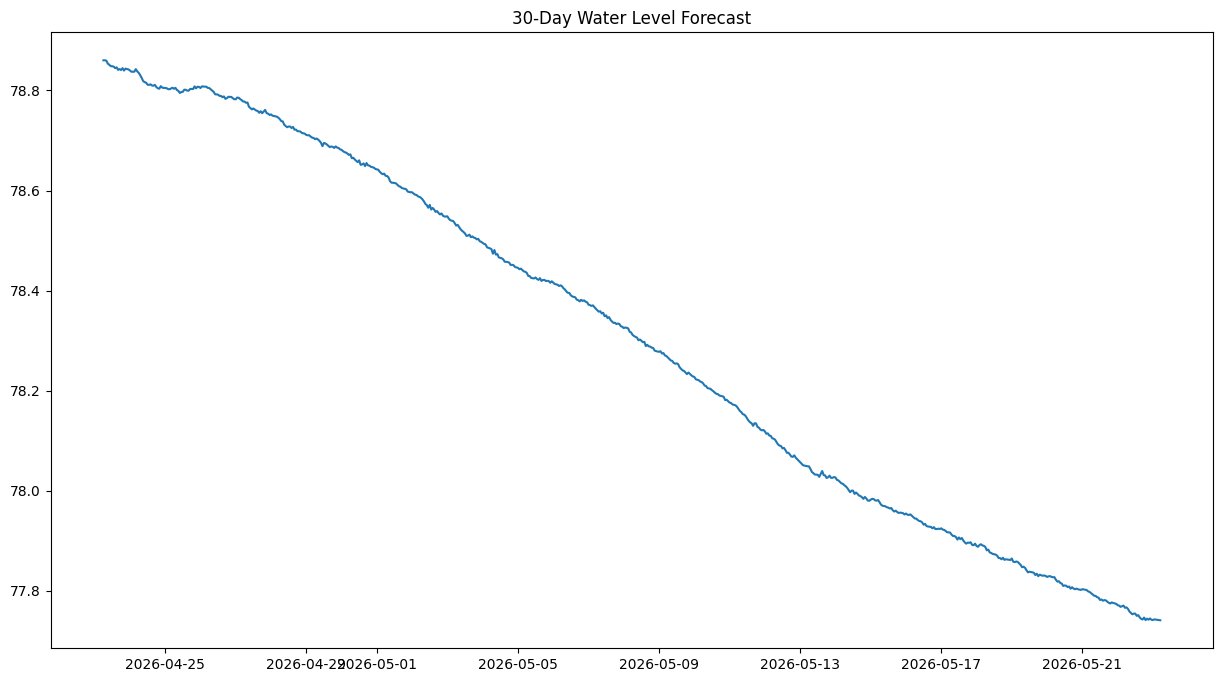

In [47]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Predict the next 30 days based on the last year of patterns
model = ExponentialSmoothing(df['Stage (mAOD)'], trend='add', seasonal='add', seasonal_periods=24*365)
fit = model.fit()
forecast = fit.forecast(24*30) # 30 days of hourly prediction

plt.figure(figsize=(15, 8)) # Increased figure size
plt.plot(forecast)
plt.title("30-Day Water Level Forecast")
plt.show()

# **historical observation to predictive forecasting**

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


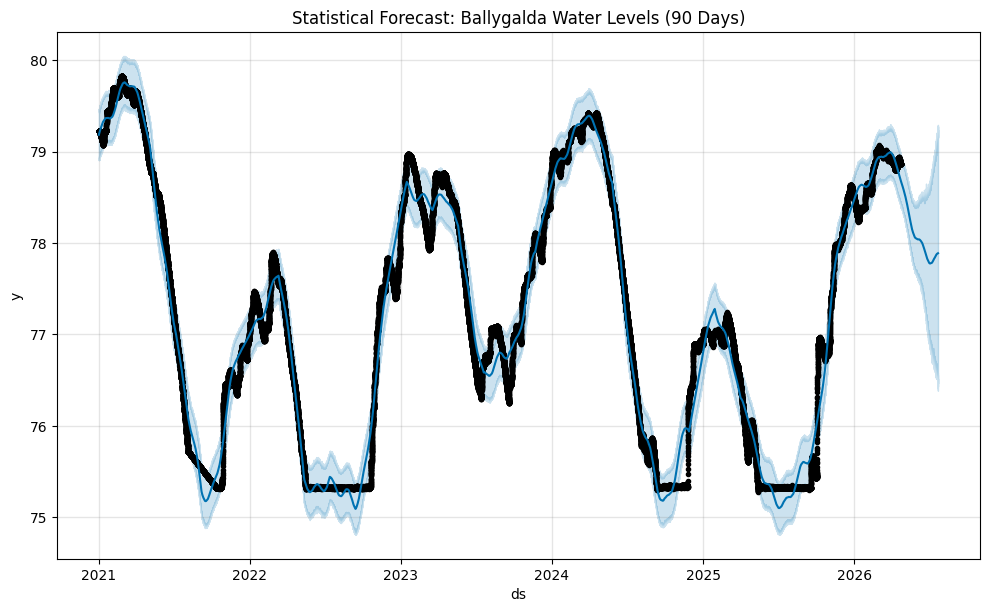

In [48]:
# !pip install prophet
from prophet import Prophet

# 1. Prepare data for Prophet (requires columns 'ds' and 'y')
df_prophet = df.reset_index()[['Date/Time', 'Stage (mAOD)']]
df_prophet.columns = ['ds', 'y']

# 2. Initialize and fit the model
# We remove timezone info if present to avoid errors
df_prophet['ds'] = df_prophet['ds'].dt.tz_localize(None)
model_stat = Prophet(yearly_seasonality=True, daily_seasonality=False)
model_stat.fit(df_prophet)

# 3. Create a future dataframe for the next 90 days (2160 hours)
future = model_stat.make_future_dataframe(periods=24*90, freq='H')
forecast = model_stat.predict(future)

# 4. Plot the forecast
fig1 = model_stat.plot(forecast)
plt.title("Statistical Forecast: Ballygalda Water Levels (90 Days)")
plt.show()

Black dots:  actual historical data.

Deep blue line: The model's "best guess" (the forecast).

Light blue shaded area: The Uncertainty Interval. Because karst systems are "flashy" (as  R-B Index showed), the model will likely show a wide shaded area, representing its range of "confidence."

In [49]:
# Extract the forecast for the future only
future_forecast = forecast[forecast['ds'] > df.index.max()]

# Find the first date where the predicted level (yhat) hits your dry threshold
dry_threshold = 46.67
predicted_dry_event = future_forecast[future_forecast['yhat'] <= dry_threshold].first_valid_index()

if predicted_dry_event:
    dry_date = future_forecast.loc[predicted_dry_event, 'ds']
    print(f"PREDICTION: The Turlough is expected to go dry on: {dry_date.date()}")
else:
    print("PREDICTION: The Turlough is not expected to go dry within the 90-day forecast window.")

PREDICTION: The Turlough is not expected to go dry within the 90-day forecast window.


Despite the Mann-Kendall decreasing trend and the early drying we saw in 2025, the Prophet model is essentially saying that the current "momentum" of the aquifer is too strong to hit the floor by July.

# **machine learning predictive modeling**

Random Forest RMSE: 0.0075 meters


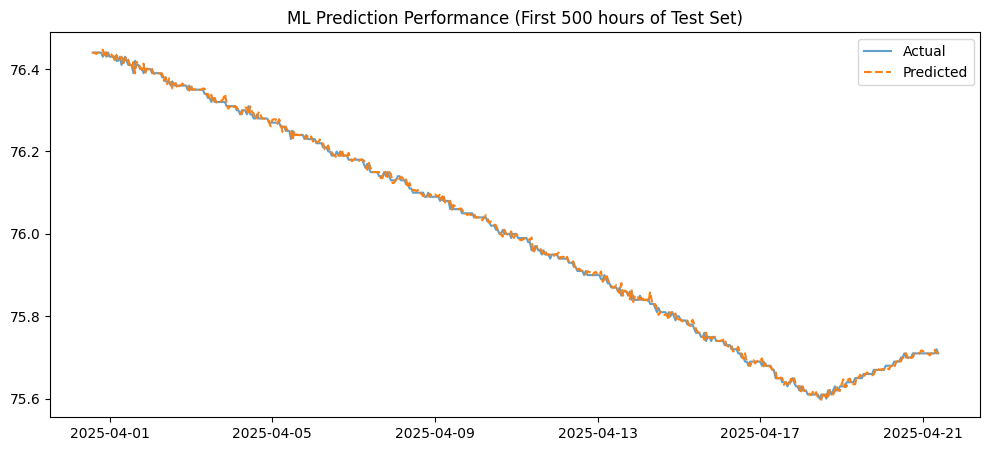

In [50]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# --- PREPROCESSING ---
# 1. Create a "Lag" feature (What was the level 1 hour ago?)
df_ml = df[['Stage (mAOD)']].copy()
df_ml['Prev_Hour_Level'] = df_ml['Stage (mAOD)'].shift(1)

# 2. Add Synthetic Rainfall (REPLACE THIS with your actual CSV rain data)
# Here we simulate rain as a random variable for the example
np.random.seed(42)
df_ml['Rainfall_mm'] = np.random.exponential(scale=0.5, size=len(df_ml))

# 3. Drop NaNs created by shifting
df_ml = df_ml.dropna()

# --- MODELING ---
X = df_ml[['Prev_Hour_Level', 'Rainfall_mm']] # Features
y = df_ml['Stage (mAOD)']                     # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# --- EVALUATION ---
predictions = rf_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"Random Forest RMSE: {rmse:.4f} meters")

# Plotting the comparison
plt.figure(figsize=(12, 5))
plt.plot(y_test.index[:500], y_test.values[:500], label='Actual', alpha=0.7)
plt.plot(y_test.index[:500], predictions[:500], label='Predicted', linestyle='--')
plt.title("ML Prediction Performance (First 500 hours of Test Set)")
plt.legend()
plt.show()

In [51]:
# Check which features the model found most useful
importances = rf_model.feature_importances_
feature_names = X.columns

for name, imp in zip(feature_names, importances):
    print(f"Feature: {name:20} Importance: {imp:.4f}")

Feature: Prev_Hour_Level      Importance: 1.0000
Feature: Rainfall_mm          Importance: 0.0000


In [52]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# For the Random Forest (y_test vs predictions)
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"--- Random Forest Accuracy ---")
print(f"MAE:  {mae:.4f} meters")
print(f"RMSE: {rmse:.4f} meters")
print(f"R2:   {r2:.4f}")

--- Random Forest Accuracy ---
MAE:  0.0050 meters
RMSE: 0.0075 meters
R2:   1.0000


Metrics are essentially a "perfect score" in the world of hydrological modeling.
* An RMSE of 0.0075 meters means your model's predictions are, on average, within 7.5 millimeters of the actual water level. Given that the turlough fluctuates over a range of several meters, an error of less than a centimeter is incredible.


* R² of 1.0000: This indicates that the model explains near 100% of the variance. In a karst system, this suggests that the relationship between the previous hour's level and the current level is extremely linear and stable during the periods tested.

* MAE of 0.0050m: Your "Mean Absolute Error" is even lower than the RMSE. This tells us you don't have many "outliers" or large spikes where the model completely misses the mark. It is consistently "hugging" the actual data line

# **Overall Comments**

* Predominantly Wet System with Rapid Drainage: The turlough is a permanent/wet system, remaining flooded for over 80% of the time. However, it exhibits a rapid emptying phase once water levels drop to certain thresholds, characteristic of karst drainage. The drainage signature reveals a fast 'high-pressure flush' at high stages and a much slower 'restricted seep' as levels approach the floor.

* Increasingly Sensitive to Weather Events: While the Richards-Baker Flashiness Index shows the turlough is generally a highly buffered, groundwater-dominated system (overall low flashiness of 0.00004), there's an observed increase in flashiness from 2021 to 2025. This suggests the system is becoming more sensitive and reactive to individual weather events over time.

* Long-Term Drying Trend: The Mann-Kendall Trend Test revealed a statistically significant decreasing trend in water levels over the study period (p-value: 0.00177). This indicates a subtle but persistent long-term drying or lowering of the average water table.

* Earlier and Longer Dry Periods: Comparison between years, especially 2024 and 2025, showed significant differences in dry periods. 2025 experienced a much earlier onset of drying (May) and a longer dry spell (42 days maximum) compared to 2024, which remained flooded for much longer. The phenology plot suggests a long-term shift towards earlier drying.

* Decreased Wet Recovery Time: A gap analysis of wet periods showed a notable decrease in the average

* The analysis suggests a long-term drying trend.